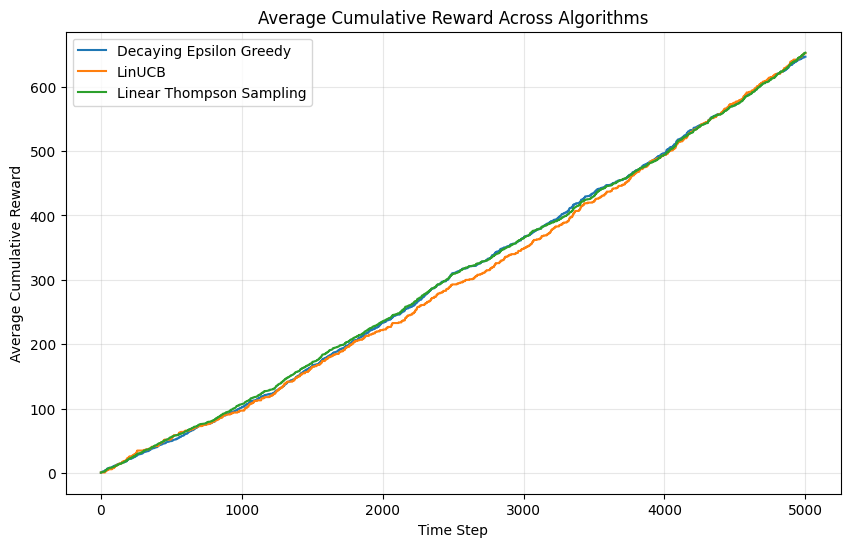

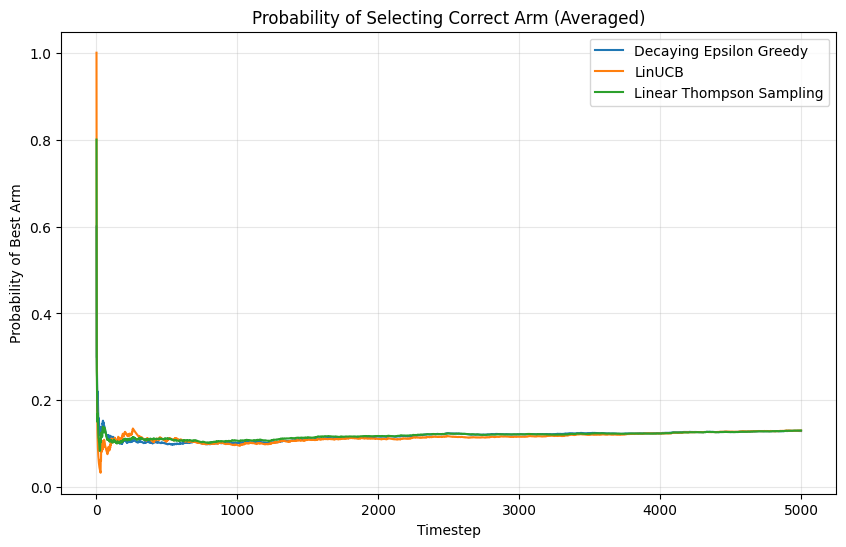

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Load the 3 generated files
files = ["results_eps.csv", "results_linucb.csv", "results_ts.csv"]
all_results = []

for f in files:
    if os.path.exists(f):
        all_results.append(pd.read_csv(f))
    else:
        print(f"Warning: {f} not found. Did the job finish?")

if not all_results:
    raise ValueError("No result files found! Cannot plot.")

# Combine into one dataframe
result_df = pd.concat(all_results, ignore_index=True)

# 2. Cumulative Reward Logic
result_df["cumulative_reward"] = (
    result_df.sort_values(["Algorithm", "Simulation", "Timestep"])
    .groupby(["Algorithm", "Simulation"])["Reward"]
    .cumsum()
)

avg_cum_reward = (
    result_df.groupby(["Algorithm", "Timestep"])["cumulative_reward"]
    .mean().reset_index()
)

# Plot Cumulative Reward
plt.figure(figsize=(10, 6))
for algo in avg_cum_reward["Algorithm"].unique():
    data = avg_cum_reward[avg_cum_reward["Algorithm"] == algo]
    plt.plot(data["Timestep"], data["cumulative_reward"], label=algo)

plt.xlabel("Time Step")
plt.ylabel("Average Cumulative Reward")
plt.title("Average Cumulative Reward Across Algorithms")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Probability of Best Arm Logic
result_df["Step"] = (
    result_df.sort_values(["Algorithm", "Simulation", "Timestep"])
    .groupby(["Algorithm", "Simulation"]).cumcount() + 1
)

result_df["Prob_Best_Arm"] = result_df["cumulative_reward"] / result_df["Step"]

avg_prob = (
    result_df.groupby(["Algorithm", "Timestep"])["Prob_Best_Arm"]
    .mean().reset_index()
)

# Plot Probability
plt.figure(figsize=(10, 6))
for algo in avg_prob["Algorithm"].unique():
    data = avg_prob[avg_prob["Algorithm"] == algo]
    plt.plot(data["Timestep"], data["Prob_Best_Arm"], label=algo)

plt.xlabel("Timestep")
plt.ylabel("Probability of Best Arm")
plt.title("Probability of Selecting Correct Arm (Averaged)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()